# Noise Signal


## Importing Libraries


In [166]:
##Scipy functions
import scipy.io.wavfile as wv
from IPython.display import Audio
from scipy.signal import stft, istft
from scipy.optimize import curve_fit

##Others
import numpy as np
import os
import matplotlib.pyplot as plt

# Main


## Import .wav file as signal


In [167]:
DATA_FOLDER_PATH = "../Data" #Specify Data folder directory here
MUSIC_FILENAME = "music.wav" #Specify music file name here
NOISE_FILENAME = "noise1.wav" #Specify noise file name here


music_filepath = os.path.join(DATA_FOLDER_PATH, MUSIC_FILENAME)
noise_filepath = os.path.join(DATA_FOLDER_PATH, NOISE_FILENAME)

In [168]:
sampleFreq, music = wv.read(music_filepath) #reading audio signal here
_, noise = wv.read(noise_filepath) #reading audio signal here

In [169]:
music = music.astype(np.float64)
noise = noise.astype(np.float64)

In [170]:
sampleLen = len(music)/sampleFreq
print(f"Sound is {sampleLen}s long")

Sound is 8.7500625s long


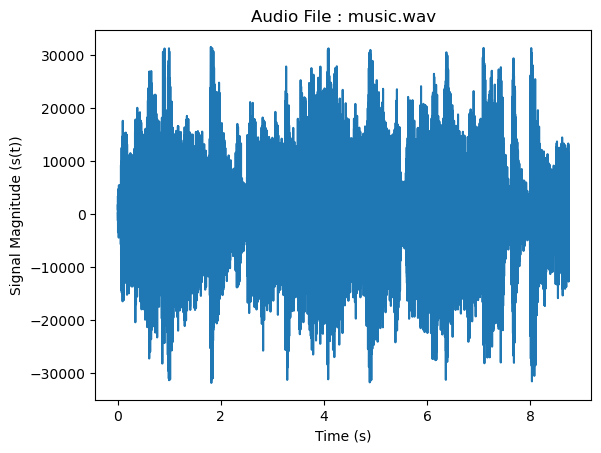

In [171]:
timeX = np.arange(0, sampleLen, 1/sampleFreq)

plt.plot(timeX, music)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [172]:
Audio(music, rate=sampleFreq)

## Generate noisy signal


In [173]:
snrdB = 10 #SNR in dB
snrLinear = 10**(snrdB / 10)

In [174]:
musicPower = np.mean(music**2)
noisePower = np.mean(noise**2)

In [175]:
targetNoisePower = musicPower / snrLinear

In [176]:
scaledNoise = noise * np.sqrt(targetNoisePower / noisePower)

In [177]:
noisySignal = music + scaledNoise

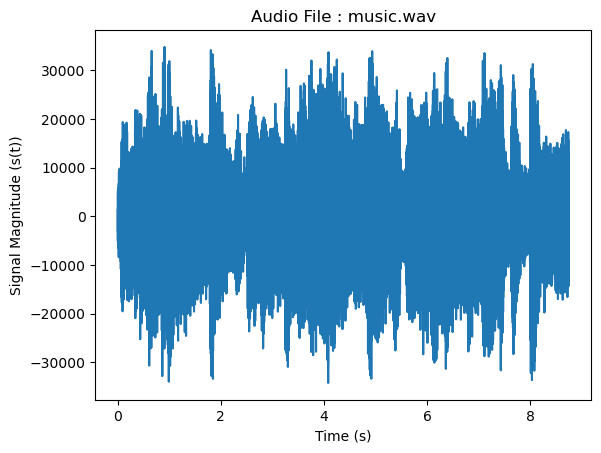

In [178]:
timeX = np.arange(0, sampleLen, 1/sampleFreq)

plt.plot(timeX, noisySignal)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [179]:
Audio(noisySignal, rate=sampleFreq)

## Calculating the STFT of the noisy signal


In [180]:
f, t, Zxx = stft(noisySignal, fs=sampleFreq, nperseg=1024)

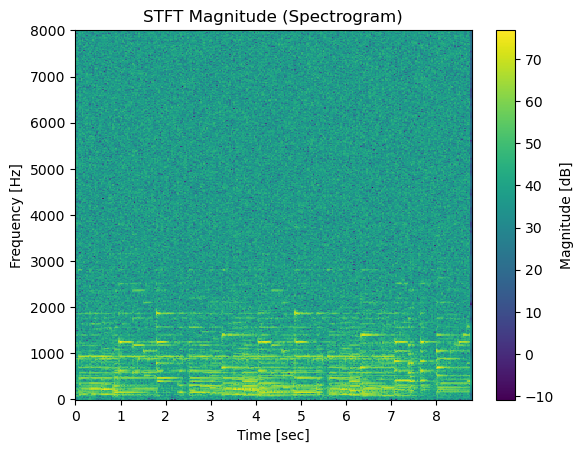

In [181]:
## Display the STFT

plt.pcolormesh(t, f, 20 * np.log10(np.abs(Zxx)))
plt.title('STFT Magnitude (Spectrogram)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Magnitude [dB]')
plt.show()

In [182]:
np.mean(abs(Zxx))

144.074229961574

## Hard Thresholding


In [183]:
## Apply Hard thresholding 

threshold = 200 #Threshold value

ZxxThresholding = np.where(np.abs(Zxx) >= threshold, Zxx, 0)

In [184]:
timeX, denoisedSignalHardThresholding = istft(ZxxThresholding, fs=sampleFreq)

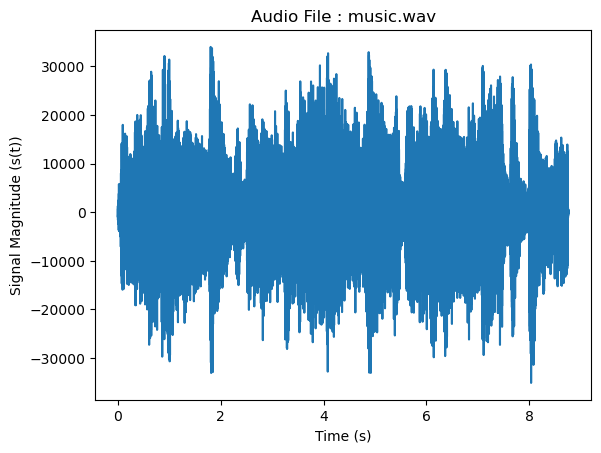

In [185]:
## Display denoised signal

plt.plot(timeX, denoisedSignalHardThresholding)
plt.xlabel("Time (s)")
plt.ylabel("Signal Magnitude (s(t))")
plt.title(f"Audio File : {MUSIC_FILENAME}")

plt.show()

In [186]:
Audio(denoisedSignalHardThresholding, rate=sampleFreq)

## Spectral Substraction


In [187]:
## Apply Spectral substraction

lambdaParameter = 100

_, _, ZxxNoise = stft(noise, fs=sampleFreq, nperseg=1024)
ZxxNoisePower = np.mean(ZxxNoise, axis=1)

ZxxSubstraction = Zxx * np.clip(1 - (((lambdaParameter ** 2) * ZxxNoisePower)/(Zxx**2)), 0)


ValueError: operands could not be broadcast together with shapes (513,) (513,275) 

In [188]:
ZxxNoisePower.shape

(513,)